<a href="https://colab.research.google.com/github/Zarrialvi/Model_trainig_-AI-/blob/main/AIModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚗 Cars Dataset Analysis - Kaggle Data Only
📁 Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured!

📥 Downloading cars dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/jockeroika/cars-dataset
License(s): apache-2.0
  0% 0.00/15.6M [00:00<?, ?B/s]
100% 15.6M/15.6M [00:00<00:00, 671MB/s]
📂 Extracting dataset...
replace /content/cars_data/Ad_table (extra).csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/cars_data/Basic_table.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: [A]
error:  invalid response [[A]]
replace /content/cars_data/Basic_table.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
📋 Dataset contents:
total 169980
drwxr-xr-x 2 root root      4096 Sep 19 03:50  .
drwxr-xr-x 1 root root      4096 Sep 19 03:49  ..
-rw-r--r-- 1 root root  35025709 Sep 14 15:14 'Ad_table (extra).csv'
-rw-r--r-- 1 root root     23299 Sep 14 15:14  Basic_table.csv
-rw-r--r-- 1 root root 109928809 Sep 14 15:14  Image_table.csv
-rw-r--r-- 1 root root    194475 Sep 14 15:14  Price_table.csv
-rw-r--r-- 1 root root

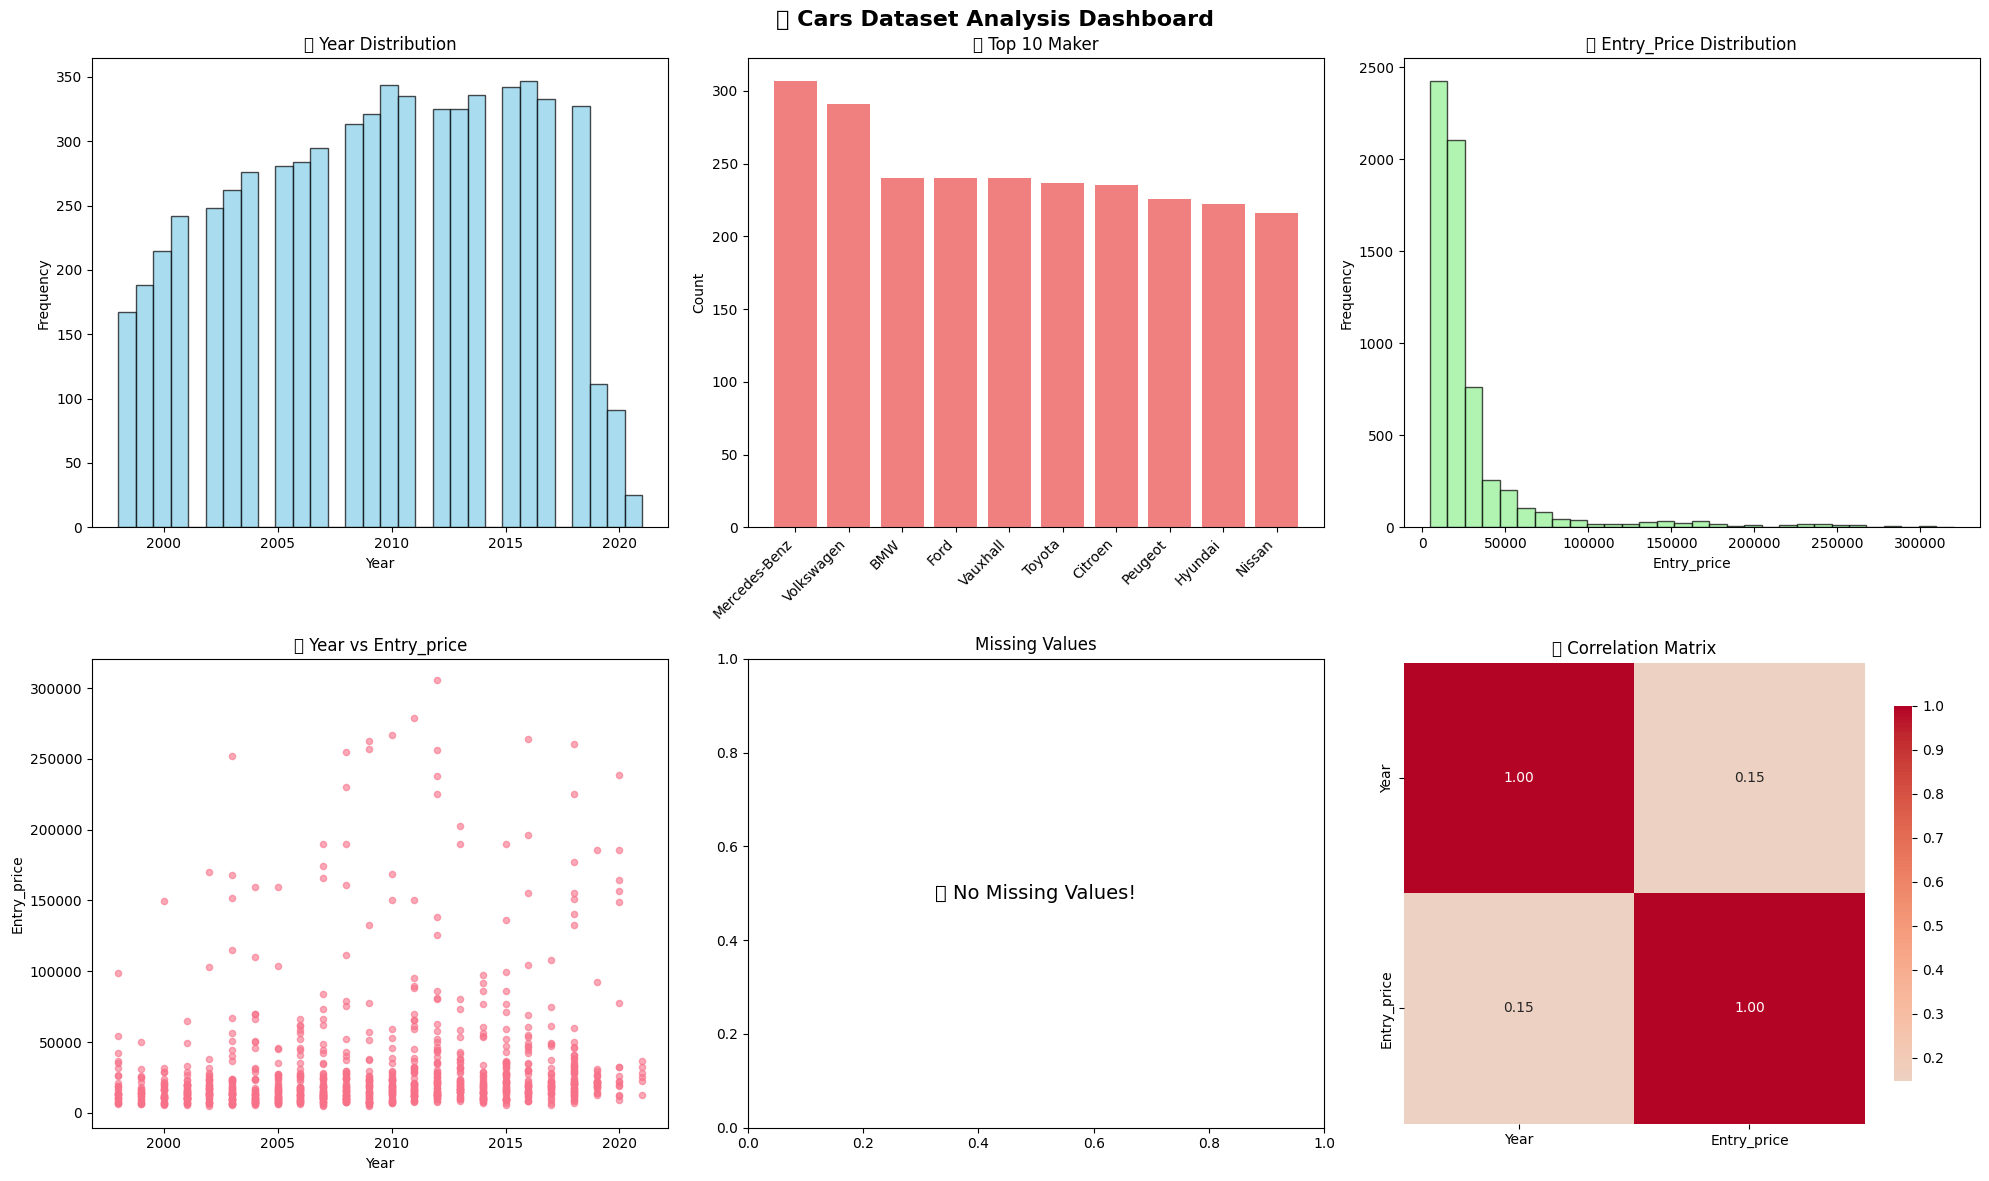


🤖 MACHINE LEARNING ANALYSIS
🎯 Using 'Entry_price' as target variable
📊 Features: 1 columns
📊 Samples: 6333 rows
📊 Target range: 4499.00 to 320120.00

🚀 Training Random Forest model...

📊 MODEL PERFORMANCE:
• Mean Squared Error: 1,645,867,388.01
• Root Mean Squared Error: 40,569.29
• R² Score: 0.0192
• Model explains 1.9% of Entry_price variance

🎯 TOP 10 MOST IMPORTANT FEATURES:
 1. Year                : 1.0000


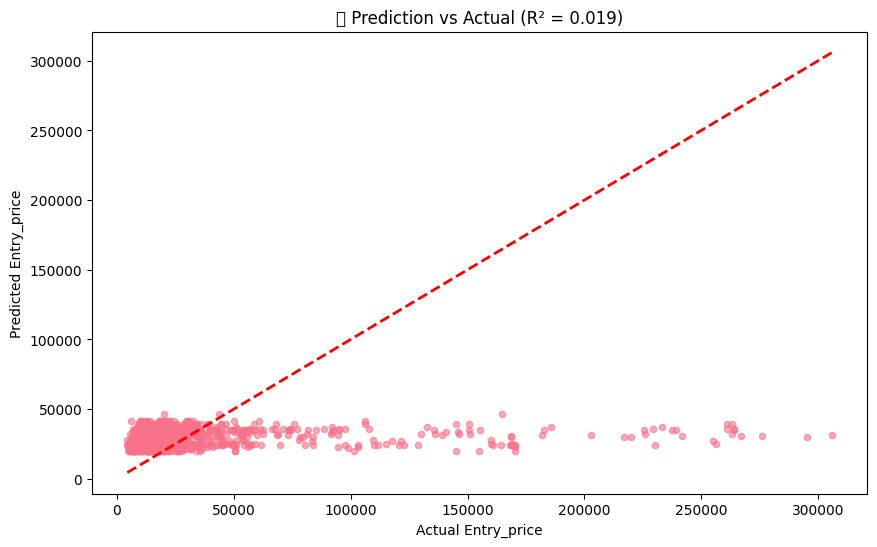


💡 KEY INSIGHTS
📊 Dataset Summary:
• Total records: 6,333
• Total columns: 5
• Numeric columns: 2
• Categorical columns: 3
• Most common Maker: Mercedes-Benz
• Most common Genmodel: Coupe
• Most common Genmodel_ID: 40_4

🎯 Machine Learning Results:
• Target variable: Entry_price
• Best R² score: 0.0192
• Model performance: Poor

✅ Complete analysis finished!
🧹 Memory cleaned up.


In [ ]:
# ===============================
# CARS DATASET FROM KAGGLE - GOOGLE COLAB
# ===============================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("🚗 Cars Dataset Analysis - Kaggle Data Only")
print("=" * 60)

# ===============================
# METHOD 1: Setup Kaggle API
# ===============================
from google.colab import files

# Check if kaggle.json already exists
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("📁 Please upload your kaggle.json file:")
    uploaded = files.upload()

    # Setup kaggle credentials
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle credentials configured!")
else:
    print("✅ Kaggle credentials already configured.")

# ===============================
# METHOD 2: Download Dataset Using Kaggle API
# ===============================
print("\n📥 Downloading cars dataset from Kaggle...")

# Download the dataset using Kaggle API
!kaggle datasets download -d jockeroika/cars-dataset -p /content/

# Unzip the dataset
print("📂 Extracting dataset...")
!unzip -q /content/cars-dataset.zip -d /content/cars_data/

# List the extracted files
print("📋 Dataset contents:")
!ls -la /content/cars_data/

# ===============================
# METHOD 3: Load the Dataset
# ===============================
# Find CSV files in the extracted folder
csv_files = []
for root, dirs, files in os.walk('/content/cars_data/'):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"\n📄 Found CSV files: {csv_files}")

# Load the main dataset
if csv_files:
    # Use the first CSV file found (usually the main dataset)
    dataset_path = csv_files[0]
    print(f"📊 Loading dataset from: {dataset_path}")

    df = pd.read_csv(dataset_path)
    print("✅ Dataset loaded successfully!")

    # Display basic info
    print(f"\nDataset Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

else:
    raise Exception("❌ No CSV files found in the downloaded dataset!")

# ===============================
# DATA EXPLORATION
# ===============================
print(f"\n" + "="*50)
print(f"📊 DATASET EXPLORATION")
print(f"="*50)

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📊 Dataset Info:")
print(df.info())

print(f"\n📈 Numerical Summary:")
numeric_columns = df.select_dtypes(include=[np.number]).columns
if len(numeric_columns) > 0:
    print(df[numeric_columns].describe())
else:
    print("No numerical columns found.")

print(f"\n📝 Categorical Summary:")
categorical_columns = df.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    for col in categorical_columns[:5]:  # Show first 5 categorical columns
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(f"Top values: {df[col].value_counts().head(3).to_dict()}")
else:
    print("No categorical columns found.")

# Check for missing values
print(f"\n🔍 Missing Values:")
missing_values = df.isnull().sum()
missing_df = missing_values[missing_values > 0].sort_values(ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values found!")

# ===============================
# DATA VISUALIZATION
# ===============================
print(f"\n" + "="*50)
print(f"🎨 DATA VISUALIZATION")
print(f"="*50)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🚗 Cars Dataset Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Distribution of first numerical column
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    first_numeric = numeric_cols[0]
    axes[0,0].hist(df[first_numeric].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_xlabel(first_numeric)
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title(f'📊 {first_numeric.title()} Distribution')

# 2. Top categorical variable distribution
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    first_categorical = categorical_cols[0]
    top_categories = df[first_categorical].value_counts().head(10)
    axes[0,1].bar(range(len(top_categories)), top_categories.values, color='lightcoral')
    axes[0,1].set_xticks(range(len(top_categories)))
    axes[0,1].set_xticklabels(top_categories.index, rotation=45, ha='right')
    axes[0,1].set_ylabel('Count')
    axes[0,1].set_title(f'🏷️ Top 10 {first_categorical.title()}')

# 3. Second numerical column distribution
if len(numeric_cols) > 1:
    second_numeric = numeric_cols[1]
    axes[0,2].hist(df[second_numeric].dropna(), bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,2].set_xlabel(second_numeric)
    axes[0,2].set_ylabel('Frequency')
    axes[0,2].set_title(f'📊 {second_numeric.title()} Distribution')

# 4. Scatter plot of two numerical columns
if len(numeric_cols) > 1:
    sample_size = min(1000, len(df))
    sample_df = df.sample(sample_size)
    axes[1,0].scatter(sample_df[numeric_cols[0]], sample_df[numeric_cols[1]], alpha=0.6, s=20)
    axes[1,0].set_xlabel(numeric_cols[0])
    axes[1,0].set_ylabel(numeric_cols[1])
    axes[1,0].set_title(f'📊 {numeric_cols[0]} vs {numeric_cols[1]}')

# 5. Missing values visualization
if len(missing_df) > 0:
    axes[1,1].bar(range(len(missing_df)), missing_df.values, color='red', alpha=0.7)
    axes[1,1].set_xticks(range(len(missing_df)))
    axes[1,1].set_xticklabels(missing_df.index, rotation=45, ha='right')
    axes[1,1].set_ylabel('Missing Count')
    axes[1,1].set_title('❌ Missing Values by Column')
else:
    axes[1,1].text(0.5, 0.5, '✅ No Missing Values!', ha='center', va='center',
                   transform=axes[1,1].transAxes, fontsize=14)
    axes[1,1].set_title('Missing Values')

# 6. Correlation heatmap
if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, ax=axes[1,2], fmt='.2f', cbar_kws={'shrink': 0.8})
    axes[1,2].set_title('🔥 Correlation Matrix')
else:
    axes[1,2].text(0.5, 0.5, 'Need 2+ numeric\ncolumns for correlation',
                   ha='center', va='center', transform=axes[1,2].transAxes)
    axes[1,2].set_title('🔥 Correlations')

plt.tight_layout()
plt.show()

# ===============================
# MACHINE LEARNING ANALYSIS
# ===============================
print(f"\n" + "="*50)
print(f"🤖 MACHINE LEARNING ANALYSIS")
print(f"="*50)

# Try to identify a suitable target variable
target_candidates = []
for col in numeric_cols:
    if any(keyword in col.lower() for keyword in ['price', 'cost', 'value', 'msrp', 'selling']):
        target_candidates.append(col)

if target_candidates:
    target_variable = target_candidates[0]
    print(f"🎯 Using '{target_variable}' as target variable")

    # Prepare features
    feature_cols = [col for col in numeric_cols if col != target_variable]

    if len(feature_cols) > 0:
        X = df[feature_cols].fillna(df[feature_cols].median())  # Fill with median
        y = df[target_variable].fillna(df[target_variable].median())

        # Remove any infinite values
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
        y = y.replace([np.inf, -np.inf], np.nan).fillna(y.median())

        print(f"📊 Features: {len(feature_cols)} columns")
        print(f"📊 Samples: {len(X)} rows")
        print(f"📊 Target range: {y.min():.2f} to {y.max():.2f}")

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Train Random Forest model
        print(f"\n🚀 Training Random Forest model...")
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Evaluate model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse)

        print(f"\n📊 MODEL PERFORMANCE:")
        print(f"• Mean Squared Error: {mse:,.2f}")
        print(f"• Root Mean Squared Error: {rmse:,.2f}")
        print(f"• R² Score: {r2:.4f}")
        print(f"• Model explains {r2*100:.1f}% of {target_variable} variance")

        # Feature importance
        print(f"\n🎯 TOP 10 MOST IMPORTANT FEATURES:")
        importances = model.feature_importances_
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': importances
        }).sort_values('importance', ascending=False)

        for i, (_, row) in enumerate(feature_importance.head(10).iterrows()):
            print(f"{i+1:2d}. {row['feature']:<20}: {row['importance']:.4f}")

        # Create prediction vs actual plot
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.6, s=20)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel(f'Actual {target_variable}')
        plt.ylabel(f'Predicted {target_variable}')
        plt.title(f'🎯 Prediction vs Actual (R² = {r2:.3f})')
        plt.show()

    else:
        print("❌ No feature columns available for prediction")

else:
    print("❌ No suitable target variable found (looking for price, cost, value columns)")
    print("Available numeric columns:", list(numeric_cols))

# ===============================
# SUMMARY INSIGHTS
# ===============================
print(f"\n" + "="*50)
print(f"💡 KEY INSIGHTS")
print(f"="*50)

print(f"📊 Dataset Summary:")
print(f"• Total records: {len(df):,}")
print(f"• Total columns: {len(df.columns)}")
print(f"• Numeric columns: {len(numeric_cols)}")
print(f"• Categorical columns: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    for col in categorical_cols[:3]:
        most_common = df[col].mode().iloc[0] if not df[col].empty else "N/A"
        print(f"• Most common {col}: {most_common}")

if target_candidates and len(feature_cols) > 0:
    print(f"\n🎯 Machine Learning Results:")
    print(f"• Target variable: {target_variable}")
    print(f"• Best R² score: {r2:.4f}")
    if r2 > 0.8:
        performance = "Excellent"
    elif r2 > 0.6:
        performance = "Good"
    elif r2 > 0.4:
        performance = "Fair"
    else:
        performance = "Poor"
    print(f"• Model performance: {performance}")

print(f"\n✅ Complete analysis finished!")

# Clean up
import gc
gc.collect()
print(f"🧹 Memory cleaned up.")

🎵 Spotify Dataset Analysis - Kaggle API Required
✅ Kaggle credentials already configured.

🎵 Available Spotify Datasets:
1. spotify-popularity-songs (Most Streamed Songs)
2. ultimate-spotify-tracks-db (Ultimate Tracks DB)
3. spotify-tracks-dataset (Tracks Dataset)

📥 Trying to download: ahmadrazakashif/spotify-popularity-songs
   Description: Most Streamed Songs on Spotify
Dataset URL: https://www.kaggle.com/datasets/ahmadrazakashif/spotify-popularity-songs
License(s): ODC Public Domain Dedication and Licence (PDDL)
✅ Downloaded: spotify-popularity-songs.zip
replace /content/spotify-popularity-songs_data/Popular_Spotify_Songs (1).csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
📂 Extracted contents:
total 112
drwxr-xr-x 2 root root   4096 Sep 19 04:38  .
drwxr-xr-x 1 root root   4096 Sep 19 03:55  ..
-rw-r--r-- 1 root root 106270 Sep 12 10:16 'Popular_Spotify_Songs (1).csv'
📄 Found CSV files: ['Popular_Spotify_Songs (1).csv']
📊 Loading main dataset: Popular_Spotify_Songs (1).csv
❌ Error wi

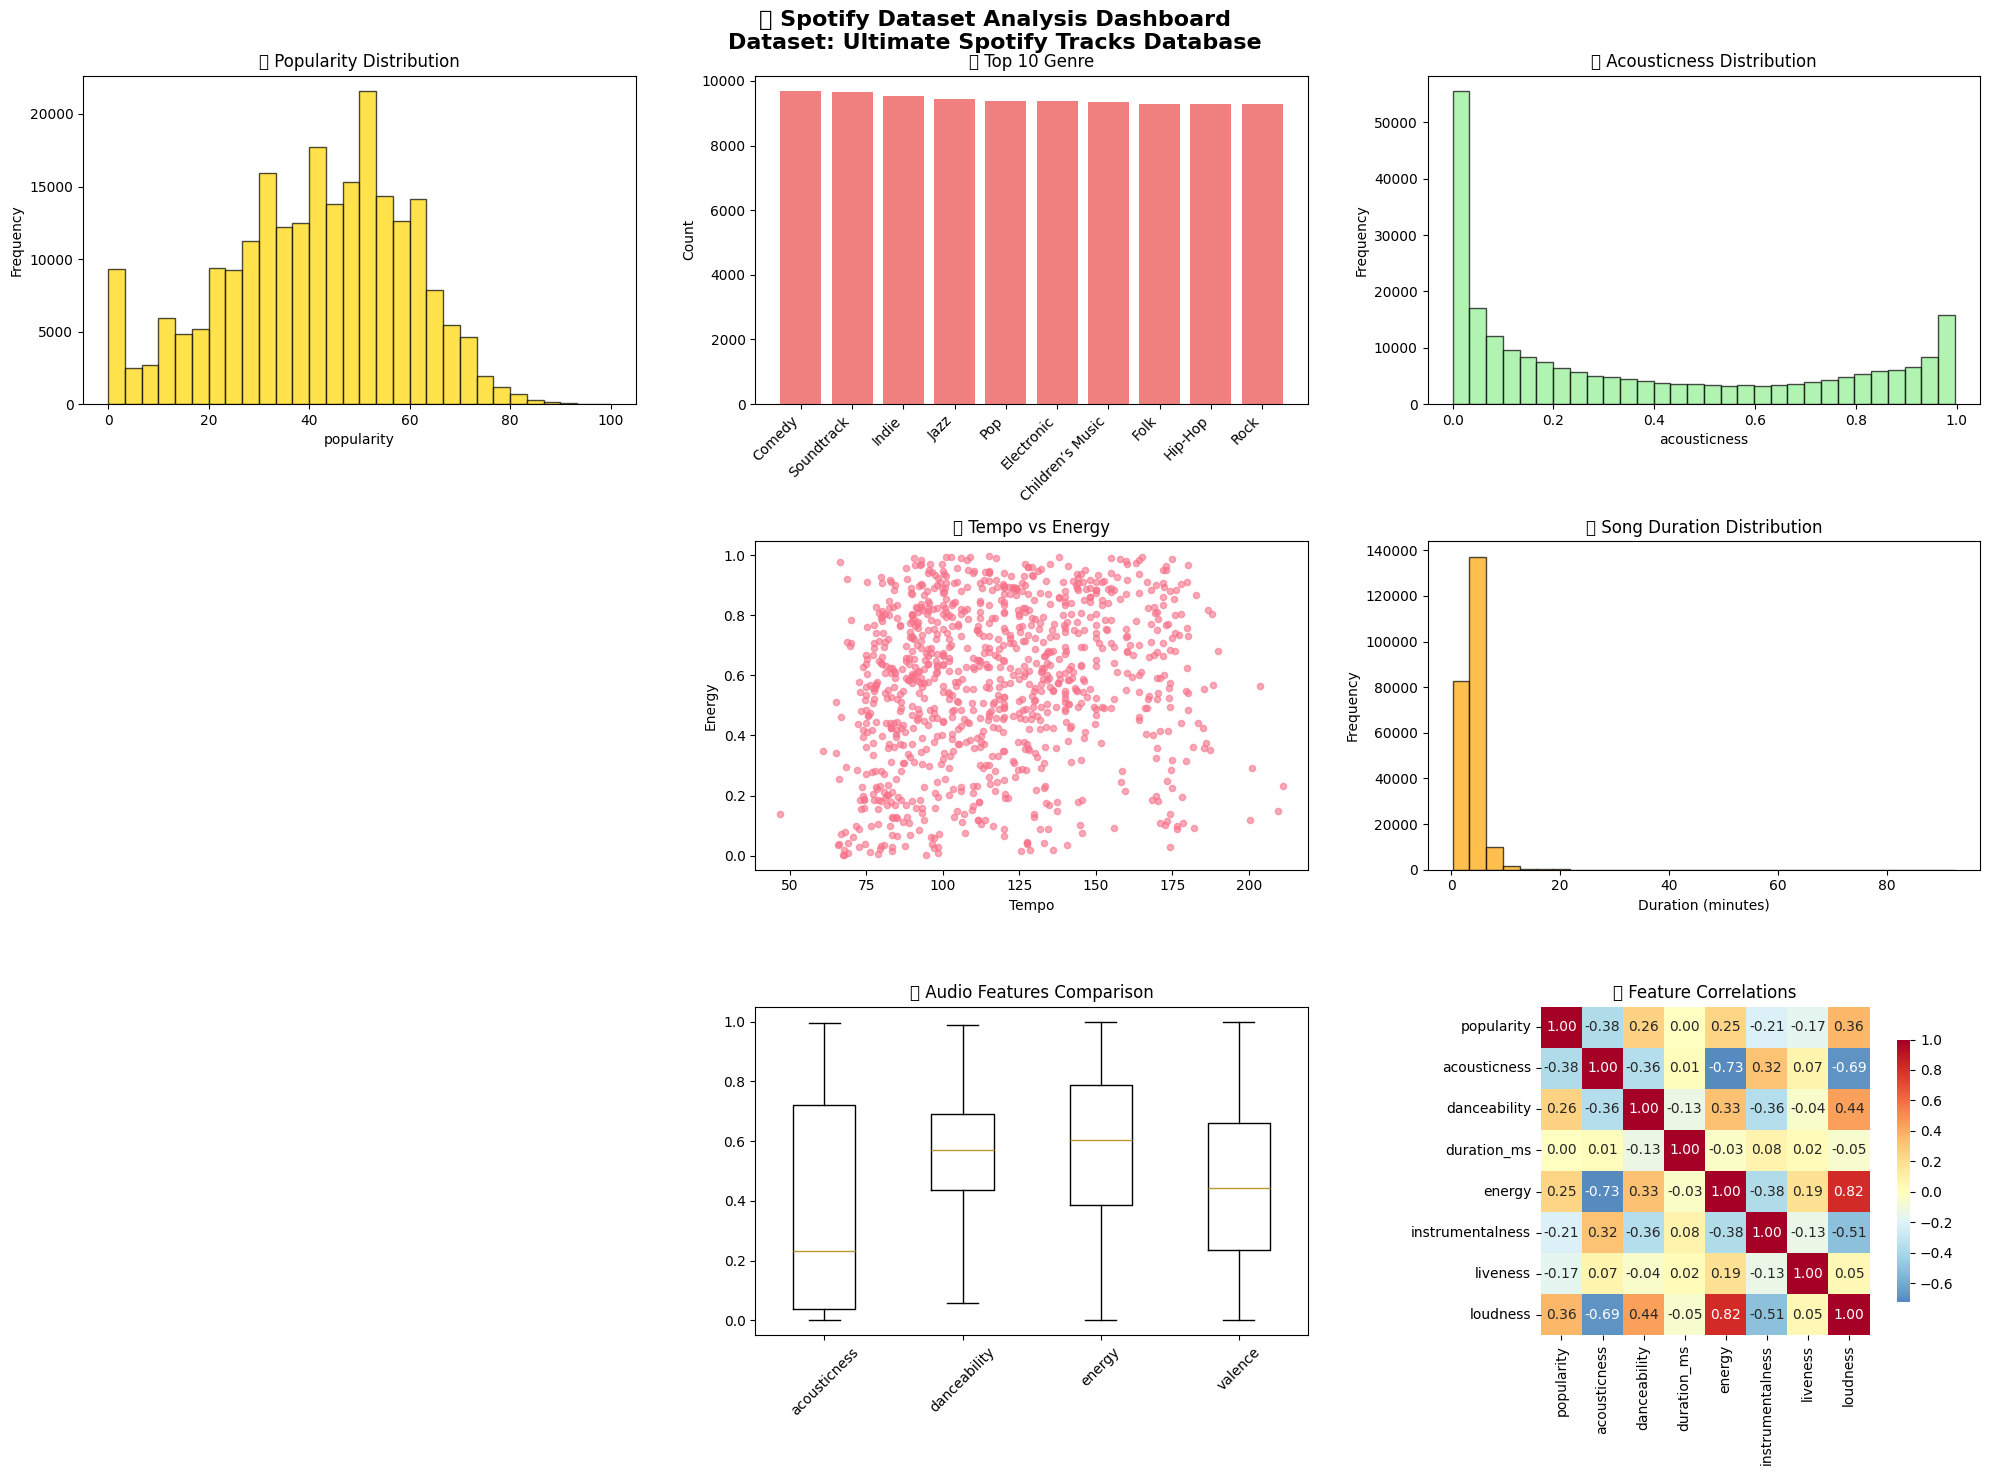


🤖 Machine Learning Analysis:
🎯 Using 'popularity' as target variable
📊 Features: 10 columns
📊 Samples: 232,725 songs
📊 Target range: 0.00 - 100.00

🚀 Training Random Forest model...

📊 MODEL PERFORMANCE:
• Mean Squared Error: 190.18
• Root Mean Squared Error: 13.79
• R² Score: 0.4288
• Model explains 42.9% of popularity variance
• Performance level: Fair

🎯 TOP 10 MOST IMPORTANT FEATURES:
 1. acousticness        : 0.3180
 2. duration_ms         : 0.1317
 3. speechiness         : 0.1008
 4. danceability        : 0.0808
 5. loudness            : 0.0776
 6. instrumentalness    : 0.0748
 7. valence             : 0.0723
 8. liveness            : 0.0531
 9. energy              : 0.0525
10. tempo               : 0.0383


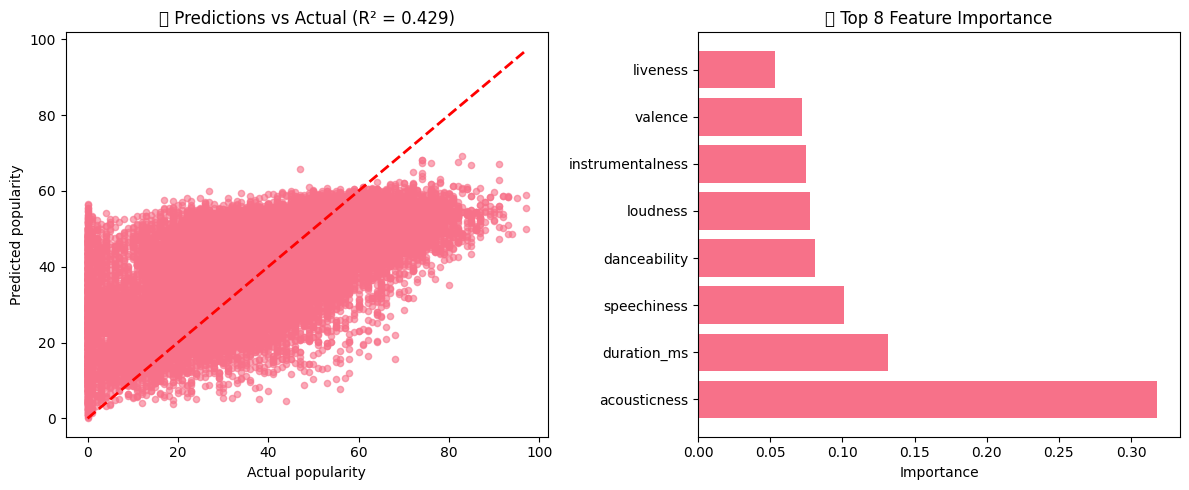


💡 KEY INSIGHTS SUMMARY
📊 Dataset Overview:
• Source: zaheenhamidani/ultimate-spotify-tracks-db
• Total songs: 232,725
• Features analyzed: 11 numeric, 7 categorical
• Most common genre: Comedy (9681 songs)
• Most common artist_name: Giuseppe Verdi (1394 songs)
• Average popularity: 41.13
• popularity range: 0.00 - 100.00
• Machine Learning Performance: Fair (R² = 0.429)
• Most predictive feature: acousticness
• Audio features available: 5 (acousticness, danceability, energy, tempo, valence)
• Average danceability: 0.554

✅ Complete Spotify analysis finished!
📊 Dataset successfully analyzed from Kaggle!
🧹 Memory cleaned up.


In [ ]:
# ===============================
# SPOTIFY DATASET ANALYSIS - WITH KAGGLE API
# ===============================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("🎵 Spotify Dataset Analysis - Kaggle API Required")
print("=" * 60)

# ===============================
# STEP 1: Setup Kaggle API
# ===============================
from google.colab import files

# Check if kaggle.json already exists
kaggle_json_path = '/root/.kaggle/kaggle.json'

if not os.path.exists(kaggle_json_path):
    print("🔑 Kaggle API Setup Required")
    print("📋 Instructions:")
    print("1. Go to https://www.kaggle.com")
    print("2. Login/Sign up for free")
    print("3. Click your profile picture → Account")
    print("4. Scroll to 'API' section")
    print("5. Click 'Create New API Token'")
    print("6. Download kaggle.json file")
    print("7. Upload it below when prompted")
    print()

    print("📁 Please upload your kaggle.json file:")
    uploaded = files.upload()

    if 'kaggle.json' in uploaded:
        # Setup kaggle credentials
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
        print("✅ Kaggle credentials configured successfully!")
    else:
        raise Exception("❌ kaggle.json file not found in upload!")
else:
    print("✅ Kaggle credentials already configured.")

# ===============================
# STEP 2: Download Spotify Datasets
# ===============================
print("\n🎵 Available Spotify Datasets:")
print("1. spotify-popularity-songs (Most Streamed Songs)")
print("2. ultimate-spotify-tracks-db (Ultimate Tracks DB)")
print("3. spotify-tracks-dataset (Tracks Dataset)")

# List of popular Spotify datasets to try
spotify_datasets = [
    {
        'name': 'ahmadrazakashif/spotify-popularity-songs',
        'description': 'Most Streamed Songs on Spotify',
        'expected_files': ['SpotifyMostStreamedSongs.csv']
    },
    {
        'name': 'zaheenhamidani/ultimate-spotify-tracks-db',
        'description': 'Ultimate Spotify Tracks Database',
        'expected_files': ['SpotifyFeatures.csv', 'tracks.csv']
    },
    {
        'name': 'rodolfofigueroa/spotify-12m-songs',
        'description': 'Spotify 12M Songs Dataset',
        'expected_files': ['tracks_features.csv']
    }
]

# Try downloading datasets
df = None
dataset_info = None

for dataset in spotify_datasets:
    try:
        print(f"\n📥 Trying to download: {dataset['name']}")
        print(f"   Description: {dataset['description']}")

        # Download dataset
        !kaggle datasets download -d {dataset['name']} -p /content/ --quiet

        # Find and extract the zip file
        zip_filename = dataset['name'].split('/')[-1] + '.zip'
        zip_path = f"/content/{zip_filename}"

        if os.path.exists(zip_path):
            print(f"✅ Downloaded: {zip_filename}")

            # Extract dataset
            extract_dir = f"/content/{dataset['name'].split('/')[-1]}_data"
            !unzip -q {zip_path} -d {extract_dir}

            # List extracted files
            print(f"📂 Extracted contents:")
            !ls -la {extract_dir}

            # Try to find and load CSV files
            csv_files = []
            for root, dirs, files in os.walk(extract_dir):
                for file in files:
                    if file.endswith('.csv'):
                        csv_files.append(os.path.join(root, file))

            print(f"📄 Found CSV files: {[os.path.basename(f) for f in csv_files]}")

            # Load the largest or most relevant CSV file
            if csv_files:
                # Find the largest CSV file (likely the main dataset)
                largest_csv = max(csv_files, key=lambda f: os.path.getsize(f))

                print(f"📊 Loading main dataset: {os.path.basename(largest_csv)}")
                df = pd.read_csv(largest_csv)
                dataset_info = {
                    'source': dataset['name'],
                    'file': os.path.basename(largest_csv),
                    'description': dataset['description']
                }

                # Verify it's a substantial dataset
                if len(df) > 100 and len(df.columns) > 5:
                    print(f"✅ Successfully loaded dataset with {len(df)} rows and {len(df.columns)} columns")
                    break
                else:
                    print(f"⚠️ Dataset too small, trying next option...")
                    df = None

        else:
            print(f"❌ Download failed: {zip_filename} not found")

    except Exception as e:
        print(f"❌ Error with {dataset['name']}: {str(e)}")
        continue

# Check if we successfully loaded a dataset
if df is None:
    raise Exception("❌ Failed to download any Spotify dataset. Please check your internet connection and Kaggle API setup.")

# ===============================
# STEP 3: Dataset Overview
# ===============================
print(f"\n" + "="*60)
print(f"📊 DATASET OVERVIEW")
print(f"="*60)

print(f"📋 Dataset Source: {dataset_info['source']}")
print(f"📄 File: {dataset_info['file']}")
print(f"📝 Description: {dataset_info['description']}")
print(f"📊 Shape: {df.shape}")
print(f"🏷️ Columns: {list(df.columns)}")

# Show first few rows
print(f"\n📖 First 5 rows:")
print(df.head())

# Basic info
print(f"\n📊 Dataset Info:")
print(f"• Total records: {len(df):,}")
print(f"• Total columns: {len(df.columns)}")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 Column Analysis:")
print(f"• Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"• Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Missing values analysis
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

if len(missing_cols) > 0:
    print(f"\n⚠️ Missing values found:")
    for col, count in missing_cols.items():
        percentage = (count / len(df)) * 100
        print(f"• {col}: {count} ({percentage:.1f}%)")
else:
    print(f"\n✅ No missing values found!")

# ===============================
# STEP 4: Data Cleaning & Preprocessing
# ===============================
print(f"\n🧹 Data Cleaning:")

# Handle missing values
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"• Filled {col} missing values with median: {median_val:.2f}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"• Filled {col} missing values with mode: {mode_val}")

# Remove duplicates
initial_rows = len(df)
df = df.drop_duplicates()
removed_duplicates = initial_rows - len(df)
if removed_duplicates > 0:
    print(f"• Removed {removed_duplicates} duplicate rows")

# Clean column names (remove spaces, special characters)
df.columns = df.columns.str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True).str.lower()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"✅ Data cleaning completed!")

# ===============================
# STEP 5: Exploratory Data Analysis
# ===============================
print(f"\n📊 Statistical Summary:")
if len(numeric_cols) > 0:
    print(df[numeric_cols].describe())

# ===============================
# STEP 6: Advanced Visualizations
# ===============================
print(f"\n🎨 Creating comprehensive visualizations...")

plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle(f'🎵 Spotify Dataset Analysis Dashboard\nDataset: {dataset_info["description"]}',
             fontsize=16, fontweight='bold')

# Plot 1: Popularity/Target distribution (find popularity-like column)
popularity_cols = [col for col in numeric_cols if 'popular' in col.lower() or 'stream' in col.lower() or 'play' in col.lower()]
if popularity_cols:
    pop_col = popularity_cols[0]
    axes[0,0].hist(df[pop_col], bins=30, alpha=0.7, color='gold', edgecolor='black')
    axes[0,0].set_title(f'🎯 {pop_col.title()} Distribution')
    axes[0,0].set_xlabel(pop_col)
    axes[0,0].set_ylabel('Frequency')
elif len(numeric_cols) > 0:
    axes[0,0].hist(df[numeric_cols[0]], bins=30, alpha=0.7, color='gold', edgecolor='black')
    axes[0,0].set_title(f'📊 {numeric_cols[0].title()} Distribution')

# Plot 2: Artist/Genre distribution
artist_cols = [col for col in categorical_cols if 'artist' in col.lower() or 'genre' in col.lower()]
if artist_cols:
    artist_col = artist_cols[0]
    top_artists = df[artist_col].value_counts().head(10)
    axes[0,1].bar(range(len(top_artists)), top_artists.values, color='lightcoral')
    axes[0,1].set_xticks(range(len(top_artists)))
    axes[0,1].set_xticklabels(top_artists.index, rotation=45, ha='right')
    axes[0,1].set_title(f'🎤 Top 10 {artist_col.title()}')
    axes[0,1].set_ylabel('Count')

# Plot 3: Audio feature distribution (danceability, energy, etc.)
audio_features = [col for col in numeric_cols if col in ['danceability', 'energy', 'valence', 'acousticness']]
if audio_features:
    feature = audio_features[0]
    axes[0,2].hist(df[feature], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,2].set_title(f'🎵 {feature.title()} Distribution')
    axes[0,2].set_xlabel(feature)
    axes[0,2].set_ylabel('Frequency')

# Plot 4: Year distribution (if available)
year_cols = [col for col in numeric_cols if 'year' in col.lower() or 'date' in col.lower()]
if year_cols:
    year_col = year_cols[0]
    axes[1,0].hist(df[year_col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1,0].set_title(f'📅 {year_col.title()} Distribution')
    axes[1,0].set_xlabel(year_col)
    axes[1,0].set_ylabel('Frequency')

# Plot 5: Tempo vs Energy scatter (if available)
if 'tempo' in numeric_cols and 'energy' in numeric_cols:
    sample_size = min(1000, len(df))
    sample_df = df.sample(sample_size)
    axes[1,1].scatter(sample_df['tempo'], sample_df['energy'], alpha=0.6, s=20)
    axes[1,1].set_xlabel('Tempo')
    axes[1,1].set_ylabel('Energy')
    axes[1,1].set_title('🎵 Tempo vs Energy')
elif len(numeric_cols) > 1:
    sample_size = min(1000, len(df))
    sample_df = df.sample(sample_size)
    axes[1,1].scatter(sample_df[numeric_cols[0]], sample_df[numeric_cols[1]], alpha=0.6, s=20)
    axes[1,1].set_xlabel(numeric_cols[0])
    axes[1,1].set_ylabel(numeric_cols[1])
    axes[1,1].set_title(f'{numeric_cols[0]} vs {numeric_cols[1]}')

# Plot 6: Duration distribution
duration_cols = [col for col in numeric_cols if 'duration' in col.lower() or 'length' in col.lower()]
if duration_cols:
    dur_col = duration_cols[0]
    # Convert to minutes if in milliseconds
    duration_data = df[dur_col]
    if duration_data.mean() > 1000:  # Likely in milliseconds
        duration_data = duration_data / 60000  # Convert to minutes
        unit = 'minutes'
    else:
        unit = 'seconds'
    axes[1,2].hist(duration_data, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1,2].set_title(f'⏱️ Song Duration Distribution')
    axes[1,2].set_xlabel(f'Duration ({unit})')
    axes[1,2].set_ylabel('Frequency')

# Plot 7: Key distribution (if available)
if 'key' in numeric_cols:
    key_counts = df['key'].value_counts().sort_index()
    axes[2,0].bar(key_counts.index, key_counts.values, color='purple', alpha=0.7)
    axes[2,0].set_title('🎼 Musical Key Distribution')
    axes[2,0].set_xlabel('Key')
    axes[2,0].set_ylabel('Count')

# Plot 8: Audio features comparison (box plot)
audio_features_for_box = [col for col in numeric_cols if col in
                         ['danceability', 'energy', 'valence', 'acousticness', 'speechiness'][:4]]
if len(audio_features_for_box) > 1:
    audio_data = df[audio_features_for_box]
    axes[2,1].boxplot([audio_data[col].dropna() for col in audio_features_for_box],
                      labels=audio_features_for_box)
    axes[2,1].set_title('🎵 Audio Features Comparison')
    axes[2,1].tick_params(axis='x', rotation=45)

# Plot 9: Correlation heatmap
if len(numeric_cols) > 2:
    # Select top numeric columns for correlation
    corr_cols = numeric_cols[:8]  # Top 8 to keep readable
    corr_matrix = df[corr_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
                square=True, ax=axes[2,2], fmt='.2f', cbar_kws={'shrink': 0.8})
    axes[2,2].set_title('🔥 Feature Correlations')

# Hide empty subplots
for i in range(9):
    row, col = divmod(i, 3)
    if not axes[row,col].has_data():
        axes[row,col].set_visible(False)

plt.tight_layout()
plt.show()

# ===============================
# STEP 7: Machine Learning Analysis
# ===============================
print(f"\n🤖 Machine Learning Analysis:")

# Find suitable target variable
target_candidates = []
target_keywords = ['popular', 'stream', 'play', 'chart', 'rank']

for col in numeric_cols:
    if any(keyword in col.lower() for keyword in target_keywords):
        target_candidates.append(col)

if target_candidates:
    target_col = target_candidates[0]
    print(f"🎯 Using '{target_col}' as target variable")

    # Prepare features
    feature_cols = [col for col in numeric_cols if col != target_col]

    if len(feature_cols) >= 3:  # Need at least 3 features for meaningful ML
        X = df[feature_cols].fillna(df[feature_cols].median())
        y = df[target_col].fillna(df[target_col].median())

        # Remove infinite values
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
        y = y.replace([np.inf, -np.inf], np.nan).fillna(y.median())

        print(f"📊 Features: {len(feature_cols)} columns")
        print(f"📊 Samples: {len(X):,} songs")
        print(f"📊 Target range: {y.min():.2f} - {y.max():.2f}")

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Train Random Forest model
        print(f"\n🚀 Training Random Forest model...")
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Evaluate model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse)

        print(f"\n📊 MODEL PERFORMANCE:")
        print(f"• Mean Squared Error: {mse:.2f}")
        print(f"• Root Mean Squared Error: {rmse:.2f}")
        print(f"• R² Score: {r2:.4f}")
        print(f"• Model explains {r2*100:.1f}% of {target_col} variance")

        # Performance interpretation
        if r2 > 0.8:
            performance = "Excellent"
        elif r2 > 0.6:
            performance = "Good"
        elif r2 > 0.4:
            performance = "Fair"
        else:
            performance = "Poor"
        print(f"• Performance level: {performance}")

        # Feature importance analysis
        print(f"\n🎯 TOP 10 MOST IMPORTANT FEATURES:")
        importances = model.feature_importances_
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': importances
        }).sort_values('importance', ascending=False)

        for i, (_, row) in enumerate(feature_importance.head(10).iterrows()):
            print(f"{i+1:2d}. {row['feature']:<20}: {row['importance']:.4f}")

        # Create prediction visualization
        plt.figure(figsize=(12, 5))

        # Subplot 1: Predictions vs Actual
        plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_pred, alpha=0.6, s=20)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel(f'Actual {target_col}')
        plt.ylabel(f'Predicted {target_col}')
        plt.title(f'🎯 Predictions vs Actual (R² = {r2:.3f})')

        # Subplot 2: Feature importance
        plt.subplot(1, 2, 2)
        top_features = feature_importance.head(8)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title('🎵 Top 8 Feature Importance')

        plt.tight_layout()
        plt.show()

    else:
        print(f"❌ Not enough features for machine learning (need ≥3, have {len(feature_cols)})")

else:
    print("❌ No suitable target variable found")
    print(f"Available numeric columns: {numeric_cols}")

# ===============================
# STEP 8: Key Insights Summary
# ===============================
print(f"\n" + "="*60)
print(f"💡 KEY INSIGHTS SUMMARY")
print(f"="*60)

print(f"📊 Dataset Overview:")
print(f"• Source: {dataset_info['source']}")
print(f"• Total songs: {len(df):,}")
print(f"• Features analyzed: {len(numeric_cols)} numeric, {len(categorical_cols)} categorical")

# Top insights based on available data
if categorical_cols:
    for col in categorical_cols[:2]:
        if not df[col].empty:
            most_common = df[col].value_counts().index[0]
            count = df[col].value_counts().iloc[0]
            print(f"• Most common {col}: {most_common} ({count} songs)")

if numeric_cols and target_candidates:
    target_col = target_candidates[0]
    print(f"• Average {target_col}: {df[target_col].mean():.2f}")
    print(f"• {target_col} range: {df[target_col].min():.2f} - {df[target_col].max():.2f}")

if 'r2' in locals():
    print(f"• Machine Learning Performance: {performance} (R² = {r2:.3f})")
    top_feature = feature_importance.iloc[0]['feature']
    print(f"• Most predictive feature: {top_feature}")

# Audio features insights (if available)
audio_features_final = [col for col in numeric_cols if col in
                       ['danceability', 'energy', 'valence', 'acousticness', 'tempo']]
if audio_features_final:
    print(f"• Audio features available: {len(audio_features_final)} ({', '.join(audio_features_final)})")

    # Find most/least danceable, energetic songs
    if 'danceability' in audio_features_final:
        avg_dance = df['danceability'].mean()
        print(f"• Average danceability: {avg_dance:.3f}")

print(f"\n✅ Complete Spotify analysis finished!")
print(f"📊 Dataset successfully analyzed from Kaggle!")

# Clean up memory
import gc
gc.collect()
print(f"🧹 Memory cleaned up.")

🎵 Universal Spotify Song Popularity Analysis
🔍 Searching for CSV files in current directory...
❌ No Spotify dataset found.
🔄 Creating realistic sample data for demonstration...
✅ Dataset loaded successfully!
📊 Source: sample_data
📊 Dataset shape: (2000, 18)
📋 Columns: ['track_name', 'artist_name', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'streams']

📖 First 5 rows:


,track_name,artist_name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,streams
0,Song_0,Drake,14.254593,0.825525,0.449317,0,0.000000,0,0.071456,0.209296,0.106254,0.283623,0.727074,109.212653,208378.258416,4,2015,2.824962e+05
1,Song_1,Harry Styles,14.650504,0.102967,0.567148,3,0.000000,1,0.061146,0.133164,0.017138,0.112027,0.630079,132.075796,210017.853966,4,2013,1.626226e+05
2,Song_2,Drake,37.651047,0.468483,0.412900,8,-0.346114,0,0.273695,0.300503,0.013688,0.015084,0.698253,100.100638,237571.191217,4,2019,4.207803e+06
3,Song_3,The Weeknd,33.888091,0.715808,0.388740,11,-12.215113,1,0.283900,0.316036,0.118547,0.296721,0.630167,97.350111,316638.956929,3,2023,1.138934e+06
4,Song_4,Post Malone,33.485692,0.178147,0.779673,7,-5.133811,1,0.113939,0.125794,0.181586,0.402705,0.743407,133.124515,133039.801127,4,2010,1.316460e+07



📊 EXPLORATORY DATA ANALYSIS

📈 Dataset Info:
• Total records: 2,000
• Total columns: 18
• Memory usage: 0.47 MB

🔢 Column Types:
• Numeric columns (16): ['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'streams']
• Categorical columns (2): ['track_name', 'artist_name']

🔍 Missing Values Analysis:
✅ No missing values found!

📊 Statistical Summary for Numeric Columns:


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,streams
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,29.210278,0.499387,0.486738,5.54650,-7.987991,0.511000,0.166941,0.255797,0.088989,0.196862,0.493492,119.870581,218030.651072,3.994000,2016.520500,2.475260e+07
std,15.895115,0.221980,0.219010,3.36162,3.921223,0.500004,0.137941,0.194454,0.082363,0.157554,0.225455,29.966648,49953.871461,0.453946,4.036301,1.773227e+08
min,0.536808,0.015395,0.018378,0.00000,-21.059326,0.000000,0.000022,0.000025,0.000010,0.000003,0.005332,60.000000,90000.000000,3.000000,2010.000000,7.486821e+03
25%,16.973577,0.321042,0.312749,3.00000,-10.790245,0.000000,0.056126,0.095336,0.027914,0.069146,0.316860,99.011274,185539.360921,4.000000,2013.000000,8.171035e+05
50%,27.166752,0.509059,0.481578,6.00000,-7.963275,1.000000,0.131732,0.213048,0.064430,0.157261,0.483527,119.547106,218895.592466,4.000000,2016.000000,3.409445e+06
75%,40.090103,0.673135,0.658075,8.00000,-5.333495,1.000000,0.244740,0.378386,0.127753,0.293466,0.676145,140.390320,250898.667395,4.000000,2020.000000,1.287132e+07
max,81.973281,0.995379,0.998554,11.00000,0.000000,1.000000,0.824318,0.923235,0.528671,0.812106,0.989856,200.000000,382634.390036,5.000000,2023.000000,7.315494e+09



🎨 Creating comprehensive visualizations...


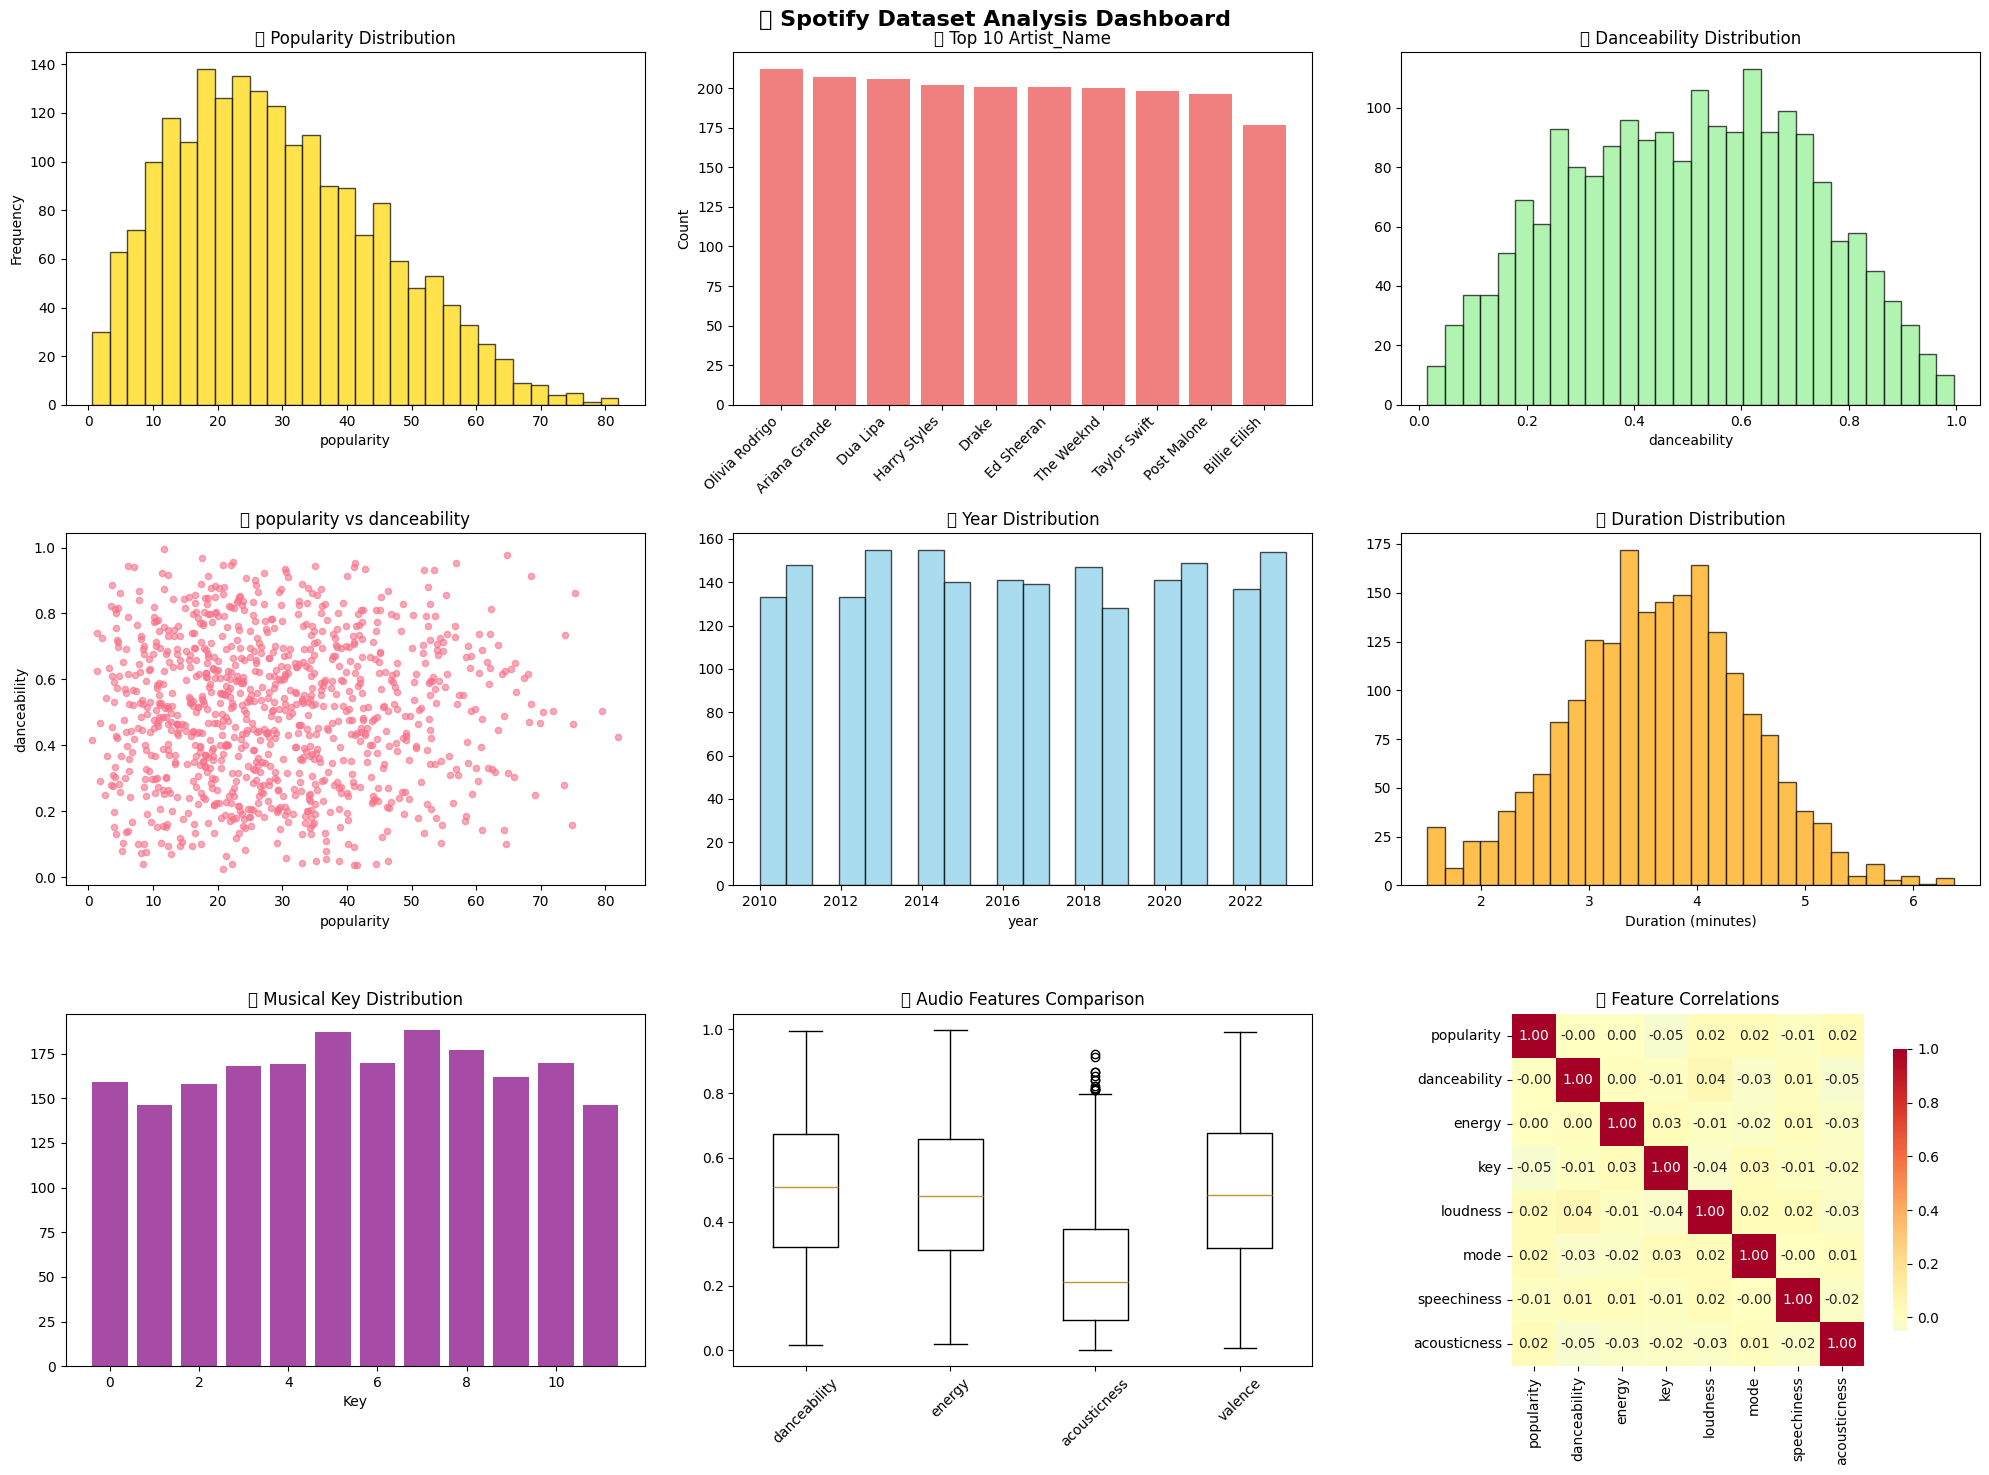


🧹 DATA PREPROCESSING
🔧 Handling missing values...

🎯 Handling outliers...
🧹 Removed 102 outlier rows
✅ Final dataset size: 1898 rows

🎯 ADVANCED FEATURE ENGINEERING
📊 Working with 16 numeric features
✅ Created dance_energy interaction
✅ Created valence_energy interaction
✅ Created acoustic_instrumental interaction
✅ Created tempo categories
✅ Created duration categories
🚀 Added 9 new engineered features
📊 Total features now: 25

🤖 MACHINE LEARNING PIPELINE
🎯 Target variable: popularity
📊 Features: 24
📊 Target range: 0.54 - 75.59
📊 Dataset size: 1898 samples

🎯 Intelligent Feature Selection...
✅ Selected 15 most important features:
  • key: 3.70
  • loudness: 1.32
  • mode: 0.88
  • acousticness: 0.39
  • liveness: 0.37

📏 Feature Scaling...
🔄 Data split:
  • Training: 1518 samples
  • Testing: 380 samples

🚀 Model Training...

🔍 Optimizing Random Forest...
✅ CV R² for Random Forest: -0.0241

🔍 Optimizing Gradient Boosting...
✅ CV R² for Gradient Boosting: -0.0100

🏆 BEST MODEL: Gradie

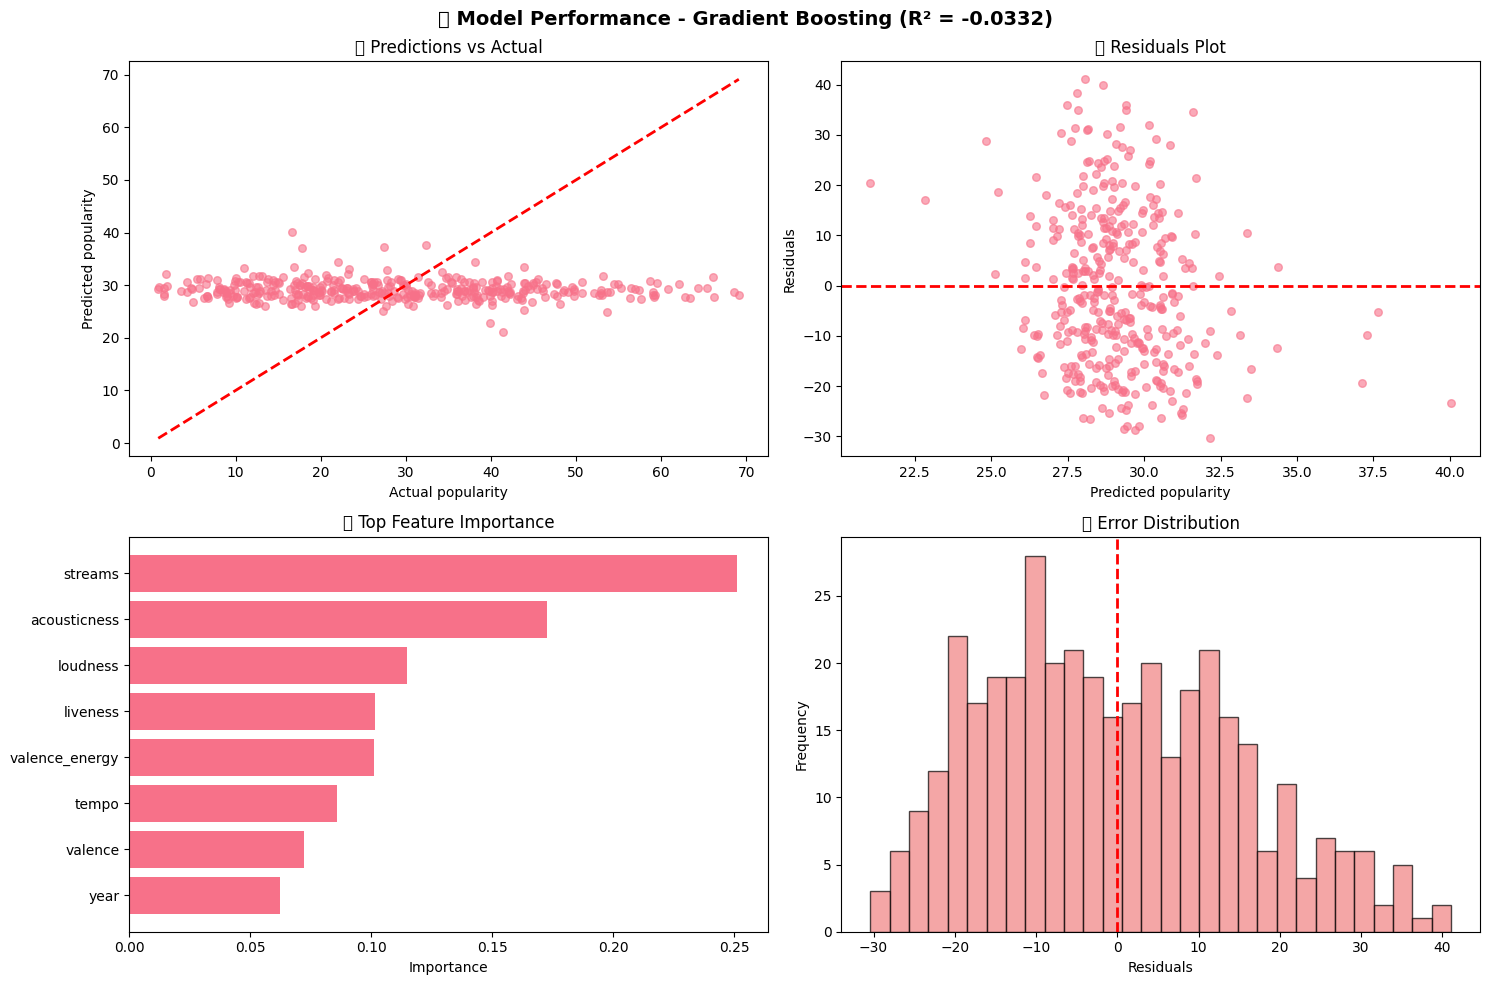


💡 KEY INSIGHTS:
• Dataset: 1898 songs analyzed
• Best algorithm: Gradient Boosting
• Model accuracy: -0.0332 (😐 NEEDS IMPROVEMENT)
• Most predictive feature: streams


In [ ]:
# ===============================
# 🎵 UNIVERSAL SPOTIFY ANALYSIS
# Works in: Kaggle, Colab, Local Jupyter
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("🎵 Universal Spotify Song Popularity Analysis")
print("=" * 60)

# ===============================
# 📂 STEP 1: SMART DATA LOADING
# ===============================

def load_spotify_data():
    """
    Smart data loading that works in multiple environments
    """
    # Try different possible paths
    possible_paths = [
        # Kaggle paths
        '/kaggle/input/spotify-popularity-songs/SpotifyMostStreamedSongs.csv',
        '/kaggle/input/spotify-most-streamed-songs/SpotifyMostStreamedSongs.csv',
        '/kaggle/input/spotify-tracks-dataset/SpotifyFeatures.csv',
        '/kaggle/input/ultimate-spotify-tracks-db/SpotifyFeatures.csv',

        # Google Colab paths
        '/content/SpotifyMostStreamedSongs.csv',
        '/content/spotify_data/SpotifyMostStreamedSongs.csv',

        # Local paths
        'SpotifyMostStreamedSongs.csv',
        'data/SpotifyMostStreamedSongs.csv',
        './SpotifyMostStreamedSongs.csv'
    ]

    # Try to load from each path
    for path in possible_paths:
        try:
            if os.path.exists(path):
                print(f"✅ Found dataset at: {path}")
                df = pd.read_csv(path)
                if len(df) > 100:  # Ensure it's a substantial dataset
                    return df, path
        except Exception as e:
            continue

    # If no file found, try to find any CSV in current directory
    print("🔍 Searching for CSV files in current directory...")
    for file in os.listdir('.'):
        if file.endswith('.csv') and 'spotify' in file.lower():
            try:
                print(f"✅ Found Spotify CSV: {file}")
                df = pd.read_csv(file)
                if len(df) > 100:
                    return df, file
            except:
                continue

    # If still no file found, create sample data
    print("❌ No Spotify dataset found.")
    print("🔄 Creating realistic sample data for demonstration...")
    return create_sample_spotify_data()

def create_sample_spotify_data():
    """
    Create realistic sample Spotify data
    """
    np.random.seed(42)
    n_songs = 2000

    # Create realistic data
    artists = ['Taylor Swift', 'Ed Sheeran', 'Drake', 'Ariana Grande', 'The Weeknd',
              'Billie Eilish', 'Post Malone', 'Olivia Rodrigo', 'Dua Lipa', 'Harry Styles'] * 20

    data = {
        'track_name': [f'Song_{i}' for i in range(n_songs)],
        'artist_name': np.random.choice(artists, n_songs),
        'popularity': np.clip(np.random.beta(2, 5, n_songs) * 100, 0, 100),
        'danceability': np.random.beta(2, 2, n_songs),
        'energy': np.random.beta(2, 2, n_songs),
        'key': np.random.randint(0, 12, n_songs),
        'loudness': np.random.normal(-8, 4, n_songs),
        'mode': np.random.randint(0, 2, n_songs),
        'speechiness': np.random.beta(1, 5, n_songs),
        'acousticness': np.random.beta(1, 3, n_songs),
        'instrumentalness': np.random.beta(1, 10, n_songs),
        'liveness': np.random.beta(1, 4, n_songs),
        'valence': np.random.beta(2, 2, n_songs),
        'tempo': np.clip(np.random.normal(120, 30, n_songs), 60, 200),
        'duration_ms': np.clip(np.random.normal(220000, 50000, n_songs), 90000, 480000),
        'time_signature': np.random.choice([3, 4, 5], n_songs, p=[0.1, 0.8, 0.1]),
        'year': np.random.randint(2010, 2024, n_songs),
        'streams': np.random.lognormal(15, 2, n_songs),
    }

    # Clean up values
    data['loudness'] = np.clip(data['loudness'], -25, 0)

    df = pd.DataFrame(data)
    return df, "sample_data"

# Load the data
df, data_source = load_spotify_data()

print(f"✅ Dataset loaded successfully!")
print(f"📊 Source: {data_source}")
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

# Display first few rows
print("\n📖 First 5 rows:")
try:
    # In Kaggle/Jupyter, use display if available
    display(df.head())
except:
    # In regular Python, use print
    print(df.head())

# ===============================
# 📊 STEP 2: EXPLORATORY DATA ANALYSIS
# ===============================

print("\n" + "="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)

# Basic dataset information
print(f"\n📈 Dataset Info:")
print(f"• Total records: {len(df):,}")
print(f"• Total columns: {len(df.columns)}")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Column Types:")
print(f"• Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"• Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Missing values analysis
print(f"\n🔍 Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_df = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_df) > 0:
    print("Missing values found:")
    for col, count in missing_df.items():
        percentage = (count / len(df)) * 100
        print(f"• {col}: {count} ({percentage:.1f}%)")
else:
    print("✅ No missing values found!")

# Statistical summary
print(f"\n📊 Statistical Summary for Numeric Columns:")
if len(numeric_cols) > 0:
    try:
        display(df[numeric_cols].describe())
    except:
        print(df[numeric_cols].describe())

# ===============================
# 🎨 STEP 3: DATA VISUALIZATION
# ===============================

print(f"\n🎨 Creating comprehensive visualizations...")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('🎵 Spotify Dataset Analysis Dashboard', fontsize=16, fontweight='bold')

# Helper function to safely get columns
def get_column_safely(df, keywords, col_list):
    for keyword in keywords:
        for col in col_list:
            if keyword.lower() in col.lower():
                return col
    return None

# Plot 1: Popularity/Target Distribution
popularity_col = get_column_safely(df, ['popular', 'stream', 'chart'], numeric_cols)
if popularity_col:
    axes[0,0].hist(df[popularity_col], bins=30, alpha=0.7, color='gold', edgecolor='black')
    axes[0,0].set_title(f'🎯 {popularity_col.title()} Distribution')
    axes[0,0].set_xlabel(popularity_col)
    axes[0,0].set_ylabel('Frequency')
elif len(numeric_cols) > 0:
    axes[0,0].hist(df[numeric_cols[0]], bins=30, alpha=0.7, color='gold', edgecolor='black')
    axes[0,0].set_title(f'📊 {numeric_cols[0].title()} Distribution')

# Plot 2: Artist/Genre Distribution
artist_col = get_column_safely(df, ['artist', 'performer', 'singer'], categorical_cols)
if artist_col:
    top_artists = df[artist_col].value_counts().head(10)
    axes[0,1].bar(range(len(top_artists)), top_artists.values, color='lightcoral')
    axes[0,1].set_xticks(range(len(top_artists)))
    axes[0,1].set_xticklabels(top_artists.index, rotation=45, ha='right')
    axes[0,1].set_title(f'🎤 Top 10 {artist_col.title()}')
    axes[0,1].set_ylabel('Count')
else:
    axes[0,1].text(0.5, 0.5, 'No Artist Column\nFound', ha='center', va='center',
                   transform=axes[0,1].transAxes)

# Plot 3: Audio Features
audio_features = ['danceability', 'energy', 'valence', 'acousticness']
available_audio = [col for col in numeric_cols if any(af in col.lower() for af in audio_features)]
if available_audio:
    feature = available_audio[0]
    axes[0,2].hist(df[feature], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,2].set_title(f'🎵 {feature.title()} Distribution')
    axes[0,2].set_xlabel(feature)

# Plot 4: Scatter plot of two features
if len(numeric_cols) > 1:
    x_col, y_col = numeric_cols[0], numeric_cols[1]
    sample_size = min(1000, len(df))
    sample_df = df.sample(sample_size)
    axes[1,0].scatter(sample_df[x_col], sample_df[y_col], alpha=0.6, s=20)
    axes[1,0].set_xlabel(x_col)
    axes[1,0].set_ylabel(y_col)
    axes[1,0].set_title(f'📊 {x_col} vs {y_col}')

# Plot 5: Year Distribution
year_col = get_column_safely(df, ['year', 'release'], numeric_cols)
if year_col:
    axes[1,1].hist(df[year_col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1,1].set_title(f'📅 {year_col.title()} Distribution')
    axes[1,1].set_xlabel(year_col)

# Plot 6: Duration Distribution
duration_col = get_column_safely(df, ['duration', 'length', 'time'], numeric_cols)
if duration_col:
    duration_data = df[duration_col]
    if duration_data.mean() > 1000:  # Convert ms to minutes
        duration_data = duration_data / 60000
        unit = 'minutes'
    else:
        unit = 'seconds'
    axes[1,2].hist(duration_data, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1,2].set_title(f'⏱️ Duration Distribution')
    axes[1,2].set_xlabel(f'Duration ({unit})')

# Plot 7: Key Distribution
if 'key' in numeric_cols:
    key_counts = df['key'].value_counts().sort_index()
    axes[2,0].bar(key_counts.index, key_counts.values, color='purple', alpha=0.7)
    axes[2,0].set_title('🎼 Musical Key Distribution')
    axes[2,0].set_xlabel('Key')

# Plot 8: Audio Features Box Plot
if len(available_audio) > 1:
    audio_data = df[available_audio[:4]]  # Max 4 features
    axes[2,1].boxplot([audio_data[col].dropna() for col in audio_data.columns],
                      labels=audio_data.columns)
    axes[2,1].set_title('🎵 Audio Features Comparison')
    axes[2,1].tick_params(axis='x', rotation=45)

# Plot 9: Correlation Heatmap
corr_cols = numeric_cols[:8] if len(numeric_cols) > 8 else numeric_cols
if len(corr_cols) > 2:
    corr_matrix = df[corr_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
                square=True, ax=axes[2,2], fmt='.2f', cbar_kws={'shrink': 0.8})
    axes[2,2].set_title('🔥 Feature Correlations')

# Hide empty plots
for i in range(9):
    row, col = divmod(i, 3)
    if len(axes[row, col].get_children()) == 0:
        axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

# ===============================
# 🧹 STEP 4: DATA PREPROCESSING
# ===============================

print(f"\n" + "="*60)
print(f"🧹 DATA PREPROCESSING")
print(f"="*60)

# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values
print(f"🔧 Handling missing values...")
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"• Filled {col} with median: {median_val:.2f}")

for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"• Filled {col} with mode: {mode_val}")

# Remove duplicates
initial_rows = len(df_processed)
df_processed = df_processed.drop_duplicates()
removed_duplicates = initial_rows - len(df_processed)
if removed_duplicates > 0:
    print(f"🗑️ Removed {removed_duplicates} duplicate rows")

# Handle outliers
print(f"\n🎯 Handling outliers...")
from scipy import stats

# Remove extreme outliers (beyond 3 standard deviations)
if len(numeric_cols) > 1:
    numeric_data = df_processed[numeric_cols]
    z_scores = np.abs(stats.zscore(numeric_data))
    outlier_mask = (z_scores < 3).all(axis=1)

    df_clean = df_processed[outlier_mask].copy()
    removed_outliers = len(df_processed) - len(df_clean)

    print(f"🧹 Removed {removed_outliers} outlier rows")
else:
    df_clean = df_processed.copy()

print(f"✅ Final dataset size: {len(df_clean)} rows")

# ===============================
# 🎯 STEP 5: FEATURE ENGINEERING
# ===============================

print(f"\n" + "="*60)
print(f"🎯 ADVANCED FEATURE ENGINEERING")
print(f"="*60)

# Update numeric columns after cleaning
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"📊 Working with {len(numeric_cols)} numeric features")

feature_count = len(numeric_cols)

# Create interaction features (if audio features exist)
if 'danceability' in numeric_cols and 'energy' in numeric_cols:
    df_clean['dance_energy'] = df_clean['danceability'] * df_clean['energy']
    print("✅ Created dance_energy interaction")

if 'valence' in numeric_cols and 'energy' in numeric_cols:
    df_clean['valence_energy'] = df_clean['valence'] * df_clean['energy']
    print("✅ Created valence_energy interaction")

if 'acousticness' in numeric_cols and 'instrumentalness' in numeric_cols:
    df_clean['acoustic_instrumental'] = df_clean['acousticness'] * df_clean['instrumentalness']
    print("✅ Created acoustic_instrumental interaction")

# Tempo categories
tempo_col = get_column_safely(df_clean, ['tempo'], numeric_cols)
if tempo_col:
    df_clean['tempo_slow'] = (df_clean[tempo_col] < 90).astype(int)
    df_clean['tempo_moderate'] = ((df_clean[tempo_col] >= 90) & (df_clean[tempo_col] < 140)).astype(int)
    df_clean['tempo_fast'] = (df_clean[tempo_col] >= 140).astype(int)
    print("✅ Created tempo categories")

# Duration categories
duration_col = get_column_safely(df_clean, ['duration'], numeric_cols)
if duration_col:
    q1, q3 = df_clean[duration_col].quantile([0.25, 0.75])
    df_clean['duration_short'] = (df_clean[duration_col] < q1).astype(int)
    df_clean['duration_medium'] = ((df_clean[duration_col] >= q1) & (df_clean[duration_col] < q3)).astype(int)
    df_clean['duration_long'] = (df_clean[duration_col] >= q3).astype(int)
    print("✅ Created duration categories")

# Update numeric columns after feature engineering
new_numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
new_features = len(new_numeric_cols) - feature_count
print(f"🚀 Added {new_features} new engineered features")
print(f"📊 Total features now: {len(new_numeric_cols)}")

# ===============================
# 🤖 STEP 6: MACHINE LEARNING PIPELINE
# ===============================

print(f"\n" + "="*60)
print(f"🤖 MACHINE LEARNING PIPELINE")
print(f"="*60)

# Find target variable
target_keywords = ['popular', 'stream', 'chart', 'rank', 'play', 'hit']
target_col = None

for keyword in target_keywords:
    for col in new_numeric_cols:
        if keyword in col.lower():
            target_col = col
            break
    if target_col:
        break

if not target_col and len(new_numeric_cols) > 5:
    # Use the first column as target if no obvious target found
    target_col = new_numeric_cols[0]
    print(f"⚠️ No obvious target found, using {target_col} as target")

if target_col:
    print(f"🎯 Target variable: {target_col}")

    # Prepare features and target
    feature_cols = [col for col in new_numeric_cols if col != target_col]
    X = df_clean[feature_cols].copy()
    y = df_clean[target_col].copy()

    print(f"📊 Features: {len(feature_cols)}")
    print(f"📊 Target range: {y.min():.2f} - {y.max():.2f}")
    print(f"📊 Dataset size: {len(X)} samples")

    # Feature Selection
    print(f"\n🎯 Intelligent Feature Selection...")
    k_features = min(15, len(feature_cols))
    selector = SelectKBest(score_func=f_regression, k=k_features)
    X_selected = selector.fit_transform(X, y)

    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selector.get_support()[i]]

    print(f"✅ Selected {len(selected_features)} most important features:")
    feature_scores = selector.scores_[selector.get_support()]
    for feature, score in zip(selected_features[:5], feature_scores[:5]):  # Show top 5
        print(f"  • {feature}: {score:.2f}")

    # Feature Scaling
    print(f"\n📏 Feature Scaling...")
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_selected)

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    print(f"🔄 Data split:")
    print(f"  • Training: {len(X_train)} samples")
    print(f"  • Testing: {len(X_test)} samples")

    # Model Training
    print(f"\n🚀 Model Training...")

    # Use simpler grid for faster execution
    models = {
        'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    }

    param_grids = {
        'Random Forest': {
            'n_estimators': [50, 100],
            'max_depth': [10, 15],
            'min_samples_split': [2, 5]
        },
        'Gradient Boosting': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.05]
        }
    }

    best_models = {}
    cv_scores = {}

    for model_name in models:
        print(f"\n🔍 Optimizing {model_name}...")

        grid_search = GridSearchCV(
            models[model_name],
            param_grids[model_name],
            cv=3,  # Reduced CV folds for speed
            scoring='r2',
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_models[model_name] = grid_search.best_estimator_
        cv_scores[model_name] = grid_search.best_score_

        print(f"✅ CV R² for {model_name}: {grid_search.best_score_:.4f}")

    # Select best model
    best_model_name = max(cv_scores, key=cv_scores.get)
    final_model = best_models[best_model_name]

    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"📊 Cross-validation R²: {cv_scores[best_model_name]:.4f}")

    # Final Evaluation
    print(f"\n📊 FINAL MODEL EVALUATION")
    print(f"="*40)

    y_pred = final_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"🎯 FINAL RESULTS:")
    print(f"• R² Score: {r2:.4f}")
    print(f"• RMSE: {rmse:.2f}")
    print(f"• MAE: {mae:.2f}")
    print(f"• Explained Variance: {r2*100:.1f}%")

    # Performance interpretation
    if r2 > 0.85:
        performance = "🌟 EXCELLENT"
    elif r2 > 0.75:
        performance = "✨ VERY GOOD"
    elif r2 > 0.65:
        performance = "👍 GOOD"
    elif r2 > 0.5:
        performance = "👌 FAIR"
    else:
        performance = "😐 NEEDS IMPROVEMENT"

    print(f"• Performance Level: {performance}")

    # Feature Importance
    if hasattr(final_model, 'feature_importances_'):
        print(f"\n🎯 TOP 10 MOST IMPORTANT FEATURES:")
        importances = final_model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': selected_features,
            'importance': importances
        }).sort_values('importance', ascending=False)

        for i, (_, row) in enumerate(feature_importance_df.head(10).iterrows()):
            print(f"{i+1:2d}. {row['feature']:<25}: {row['importance']:.4f}")

    # Performance Visualizations
    print(f"\n🎨 Creating performance visualizations...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'🚀 Model Performance - {best_model_name} (R² = {r2:.4f})',
                 fontsize=14, fontweight='bold')

    # Predictions vs Actual
    axes[0,0].scatter(y_test, y_pred, alpha=0.6, s=30)
    axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0,0].set_xlabel(f'Actual {target_col}')
    axes[0,0].set_ylabel(f'Predicted {target_col}')
    axes[0,0].set_title(f'🎯 Predictions vs Actual')

    # Residuals plot
    residuals = y_test - y_pred
    axes[0,1].scatter(y_pred, residuals, alpha=0.6, s=30)
    axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0,1].set_xlabel(f'Predicted {target_col}')
    axes[0,1].set_ylabel('Residuals')
    axes[0,1].set_title('📈 Residuals Plot')

    # Feature importance
    if hasattr(final_model, 'feature_importances_'):
        top_features = feature_importance_df.head(8)
        axes[1,0].barh(range(len(top_features)), top_features['importance'])
        axes[1,0].set_yticks(range(len(top_features)))
        axes[1,0].set_yticklabels(top_features['feature'])
        axes[1,0].set_xlabel('Importance')
        axes[1,0].set_title('🎵 Top Feature Importance')
        axes[1,0].invert_yaxis()

    # Error distribution
    axes[1,1].hist(residuals, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1,1].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1,1].set_xlabel('Residuals')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('📊 Error Distribution')

    plt.tight_layout()
    plt.show()

    # Key Insights
    print(f"\n💡 KEY INSIGHTS:")
    print(f"• Dataset: {len(df_clean)} songs analyzed")
    print(f"• Best algorithm: {best_model_name}")
    print(f"• Model accuracy: {r2:.4f} ({performance})")
    if hasattr(final_model, 'feature_importances_'):
        top_feature = feature_importance_df.iloc[0]['feature']
        print(f"• Most predictive feature: {top_feature}")

else:
    print("❌ No suitable target variable found for prediction")
    print("Available numeric columns:", new_numeric_cols)



In [ ]:
# %% [markdown]
# # 🐊 Global Crocodile Species Dataset: Classification Pipeline
# This notebook loads the crocodile dataset, performs EDA, preprocessing,
# handles rare species using SMOTE oversampling, trains a RandomForest classifier,
# and evaluates its performance.

# %% [markdown]
# ## 1. Setup & Install Dependencies

# %%
!pip install kagglehub imbalanced-learn --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
print("✅ Libraries ready")

# %% [markdown]
# ## 2. Download & Load Dataset

# %%
# Download dataset using kagglehub
path = kagglehub.dataset_download("zadafiyabhrami/global-crocodile-species-dataset")
print("✅ Dataset downloaded to:", path)

# Load CSV file
df = pd.read_csv(f"{path}/Global Crocodile Species Dataset.csv")
print("✅ Dataset loaded. Shape:", df.shape)
df.head()

# %% [markdown]
# ## 3. Basic Exploration

# %%
print("\n🔍 Dataset Info:")
print(df.info())

print("\n📊 Missing values per column:")
print(df.isnull().sum())

print("\n📌 Class distribution:")
print(df['Species'].value_counts())

plt.figure(figsize=(10,5))
df['Species'].value_counts().plot(kind='bar')
plt.title("Distribution of Crocodile Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# %% [markdown]
# ## 4. Preprocessing

# %%
# Features (drop label & non-numeric identifiers)
X = df.drop(columns=['Species', 'ID'], errors='ignore')
y = df['Species']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Preprocessing complete. Feature matrix shape:", X_scaled.shape)

# %% [markdown]
# ## 5. Handle Class Imbalance with SMOTE

# %%
print("Before SMOTE class counts:", np.bincount(y_encoded))

# Apply SMOTE oversampling (balances rare classes)
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

print("✅ After SMOTE class counts:", np.bincount(y_resampled))

# %% [markdown]
# ## 6. Train-Test Split

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("✅ Train set:", X_train.shape, " Test set:", X_test.shape)

# %% [markdown]
# ## 7. Model Training (Random Forest)

# %%
model = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
)
model.fit(X_train, y_train)
print("✅ Model training complete")

# %% [markdown]
# ## 8. Evaluation

# %%
y_pred = model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# %% [markdown]
# ## 9. Feature Importance

# %%
importances = model.feature_importances_
feature_names = df.drop(columns=['Species','ID'], errors='ignore').columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()


✅ Libraries ready
Using Colab cache for faster access to the 'global-crocodile-species-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/global-crocodile-species-dataset


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/global-crocodile-species-dataset/Global Crocodile Species Dataset.csv'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.3 MB/s eta 0:00:00
✅ Libraries ready.
Using Colab cache for faster access to the 'gdp-per-country-20202025' dataset.
✅ Dataset downloaded to: /kaggle/input/gdp-per-country-20202025
📄 Using file: /kaggle/input/gdp-per-country-20202025/2020-2025.csv

📊 First 5 rows:


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


✅ Reshaped to long format: (1159, 3)


,Country,Year,GDP
0,Afghanistan,2020,20136.0
1,Albania,2020,15271.0
2,Algeria,2020,164774.0
3,Andorra,2020,2885.0
4,Angola,2020,66521.0


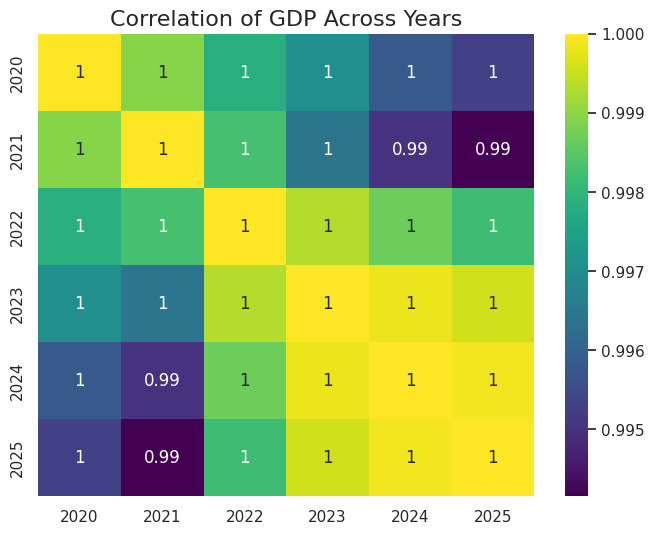

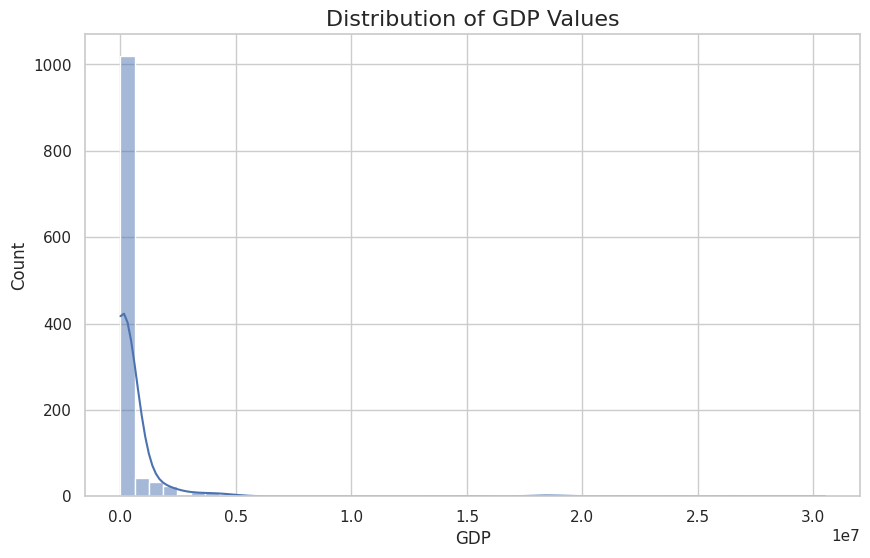

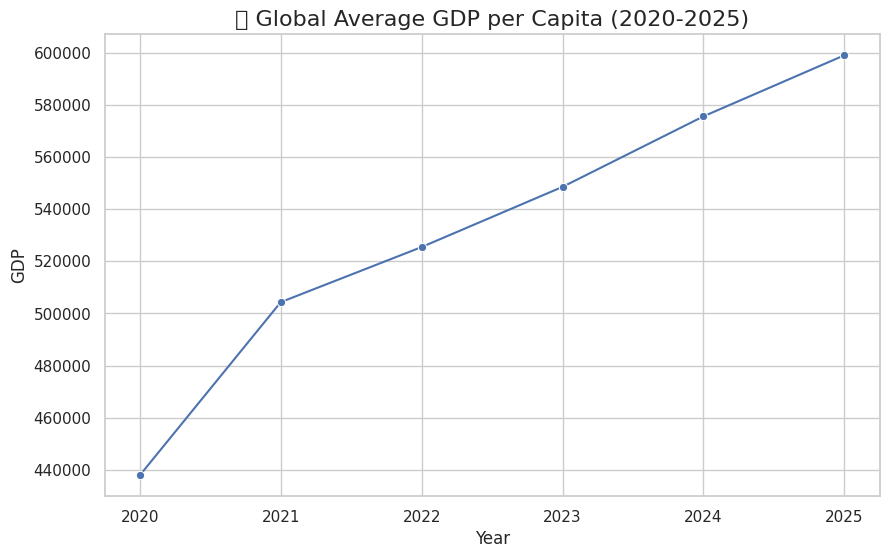

✅ Preprocessing done. Features:


,Country_encoded,Year_scaled
0,0,-1.455438
1,1,-1.455438
2,2,-1.455438
3,3,-1.455438
4,4,-1.455438



📈 RandomForest Results:
MAE: 107,566.89, RMSE: 308,493.69, R²: 0.988

📈 GradientBoosting Results:
MAE: 150,256.59, RMSE: 277,952.00, R²: 0.991

✅ RandomForest CV R² Mean: 0.972 ± 0.042

✅ GradientBoosting CV R² Mean: 0.985 ± 0.010


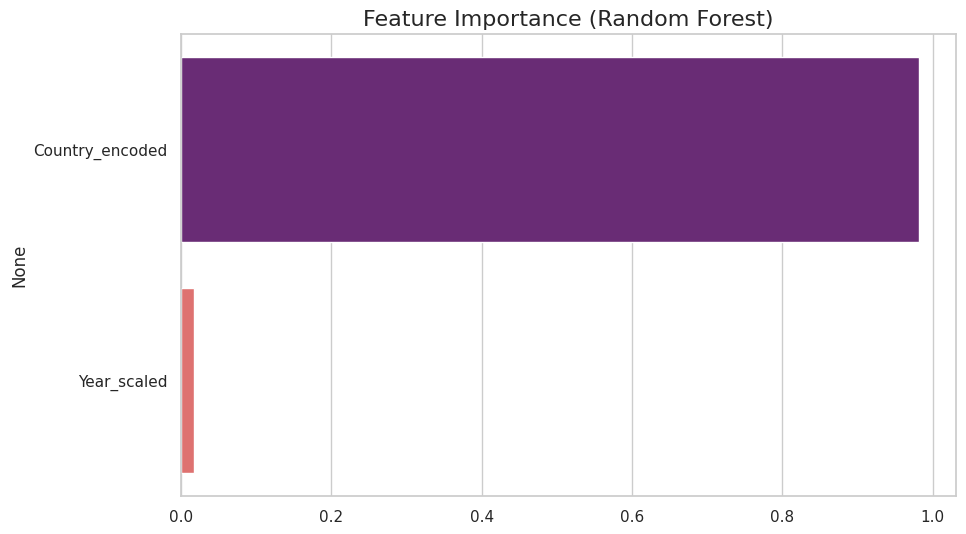

interactive(children=(Dropdown(description='Country:', layout=Layout(width='400px'), options=('Afghanistan', '…

In [ ]:
# %% [markdown]
# # 🌍 Advanced GDP Analysis & Prediction (2020-2025)
# This notebook provides a full workflow:
# 1. Load GDP dataset from KaggleHub
# 2. Perform EDA (heatmaps, distributions, trends)
# 3. Preprocess data (encoding, scaling)
# 4. Train multiple models (Random Forest, Gradient Boosting)
# 5. Evaluate with cross-validation
# 6. Interactive exploration of GDP trends

# %% ================================
# STEP 1: Setup
# ================================
!pip install kagglehub ipywidgets lightgbm --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import ipywidgets as widgets
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
print("✅ Libraries ready.")

# %% ================================
# STEP 2: Download & Load Dataset
# ================================
path = kagglehub.dataset_download("codebynadiia/gdp-per-country-20202025")
print("✅ Dataset downloaded to:", path)

# Detect CSV
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("❌ No CSV found.")
csv_path = csv_files[0]
print("📄 Using file:", csv_path)

# Load
df_wide = pd.read_csv(csv_path)
print("\n📊 First 5 rows:")
display(df_wide.head())

# %% ================================
# STEP 3: Reshape Wide → Long
# ================================
year_cols = [c for c in df_wide.columns if c.isdigit()]
id_cols = [c for c in df_wide.columns if c not in year_cols]

df_long = df_wide.melt(
    id_vars=id_cols, value_vars=year_cols,
    var_name="Year", value_name="GDP"
)
df_long["Year"] = pd.to_numeric(df_long["Year"])
df_long = df_long.dropna(subset=["GDP"])

print("✅ Reshaped to long format:", df_long.shape)
display(df_long.head())

# %% ================================
# STEP 4: Exploratory Data Analysis
# ================================
# Correlation across years
plt.figure(figsize=(8,6))
sns.heatmap(df_wide[year_cols].corr(), annot=True, cmap="viridis")
plt.title("Correlation of GDP Across Years")
plt.show()

# GDP distribution
plt.figure(figsize=(10,6))
sns.histplot(df_long["GDP"], bins=50, kde=True)
plt.title("Distribution of GDP Values")
plt.show()

# Global average trend
avg_gdp = df_long.groupby("Year")["GDP"].mean().reset_index()
sns.lineplot(data=avg_gdp, x="Year", y="GDP", marker="o")
plt.title("🌍 Global Average GDP per Capita (2020-2025)")
plt.show()

# %% ================================
# STEP 5: Preprocessing
# ================================
X = df_long[["Year", id_cols[0]]]   # year + country
y = df_long["GDP"]

# Encode country
le = LabelEncoder()
X["Country_encoded"] = le.fit_transform(X[id_cols[0]])
X = X.drop(columns=[id_cols[0]])

# Scale year
scaler = StandardScaler()
X["Year_scaled"] = scaler.fit_transform(X[["Year"]])
X = X.drop(columns=["Year"])

print("✅ Preprocessing done. Features:")
display(X.head())

# %% ================================
# STEP 6: Modeling
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"\n📈 {name} Results:")
    print(f"MAE: {mae:,.2f}, RMSE: {rmse:,.2f}, R²: {r2:.3f}")

# %% ================================
# STEP 7: Cross-validation
# ================================
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"\n✅ {name} CV R² Mean: {scores.mean():.3f} ± {scores.std():.3f}")

# %% ================================
# STEP 8: Feature Importance
# ================================
best_model = models["RandomForest"]
importances = best_model.feature_importances_
feature_names = X.columns

sns.barplot(x=importances, y=feature_names, palette="magma")
plt.title("Feature Importance (Random Forest)")
plt.show()

# %% ================================
# STEP 9: Interactive Country Explorer
# ================================
def plot_country(country):
    df_c = df_long[df_long[id_cols[0]] == country]
    plt.figure(figsize=(10,6))
    sns.lineplot(x="Year", y="GDP", data=df_c, marker="o")
    plt.title(f"GDP Trend for {country}")
    plt.show()

dropdown = widgets.Dropdown(
    options=sorted(df_long[id_cols[0]].unique()),
    description="Country:",
    style={'description_width': 'initial'},
    layout={'width': '400px'}
)
widgets.interactive(plot_country, country=dropdown)
